# Grid Shuffle Robustness Test

Tests whether nudity detection models rely on **global spatial structure** or **local pixel patterns** by:
1. Splitting an image into an N×N grid of rectangles
2. Shuffling the pieces so **no piece stays in its original position** (derangement)
3. Saving the shuffled image
4. Running all 4 models on each shuffled variant

Hypothesis: models that use global features (ViT attention, ResNet global pooling) should lose confidence as grid gets finer. Models that detect local textures/body parts (NudeNet) may stay robust.

## 0. Setup

In [16]:
import sys
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())


In [2]:
import random
import json
import time
import warnings
import logging
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw, ImageFont

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)

from detectors import create_detector

# ── Configuration ─────────────────────────────────────────────────────────────
# Path to source images
IMG_DIR = Path('../imgs')

# Image to test (should be the nude one for maximum signal)
SOURCE_IMAGE = IMG_DIR / 'img1.jpg'

# Where to save shuffled images
OUT_DIR = Path('../imgs/shuffled')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Grid sizes to test: each value N means an N×N grid (N² pieces)
GRID_SIZES = [2, 3, 4, 6, 8]

# Random seed for reproducibility
SEED = 42

# Models to evaluate
MODELS = ['nudenet', 'nudedetector', 'laion_nsfw', 'open_nsfw']
THRESHOLD = 0.7

print(f'Source image : {SOURCE_IMAGE}  exists={SOURCE_IMAGE.exists()}')
print(f'Output dir   : {OUT_DIR}')
print(f'Grid sizes   : {GRID_SIZES}  → {[n*n for n in GRID_SIZES]} pieces each')

Source image : ../imgs/img1.jpg  exists=True
Output dir   : ../imgs/shuffled
Grid sizes   : [2, 3, 4, 6, 8]  → [4, 9, 16, 36, 64] pieces each


## 1. Grid Shuffle Utilities

In [3]:
def make_derangement(n: int, rng: random.Random) -> list[int]:
    """
    Return a permutation of range(n) where no element is at its original index.
    Uses repeated Fisher-Yates until a derangement is found (fast for n >= 2).
    """
    if n < 2:
        raise ValueError('Need at least 2 pieces to shuffle.')
    indices = list(range(n))
    while True:
        rng.shuffle(indices)
        if all(indices[i] != i for i in range(n)):
            return indices


def split_grid(image: Image.Image, grid_n: int) -> tuple[list, list]:
    """
    Split `image` into grid_n × grid_n rectangles.

    Returns
    -------
    cells     : list of PIL.Image crops in row-major order
    positions : list of (x0, y0, x1, y1) bounding boxes matching each cell
    """
    W, H = image.size
    cw = W / grid_n   # float — handles non-divisible sizes cleanly
    ch = H / grid_n
    cells, positions = [], []
    for row in range(grid_n):
        for col in range(grid_n):
            x0, y0 = int(col * cw),       int(row * ch)
            x1, y1 = int((col+1) * cw),   int((row+1) * ch)
            # Last row/col extends to image edge to avoid 1-pixel gaps
            if col == grid_n - 1: x1 = W
            if row == grid_n - 1: y1 = H
            cells.append(image.crop((x0, y0, x1, y1)))
            positions.append((x0, y0, x1, y1))
    return cells, positions


def shuffle_image(
    image: Image.Image,
    grid_n: int,
    seed: int = 42
) -> tuple[Image.Image, list[int]]:
    """
    Split `image` into grid_n×grid_n pieces, apply a derangement shuffle,
    and paste pieces back into a new image.

    Parameters
    ----------
    image  : source PIL image
    grid_n : number of divisions per axis (grid_n² total pieces)
    seed   : random seed for reproducibility

    Returns
    -------
    shuffled : new PIL image with pieces in deranged positions
    order    : derangement permutation applied  (order[dst] = src)
    """
    rng = random.Random(seed)
    cells, positions = split_grid(image, grid_n)
    order = make_derangement(len(cells), rng)

    result = Image.new(image.mode, image.size)
    for dst_idx, src_idx in enumerate(order):
        x0, y0, x1, y1 = positions[dst_idx]
        piece = cells[src_idx]
        # Resize piece to fit destination slot (handles rounding differences)
        piece = piece.resize((x1 - x0, y1 - y0), Image.LANCZOS)
        result.paste(piece, (x0, y0))

    return result, order


print('Utilities loaded.')
# Quick sanity check
_d = make_derangement(9, random.Random(0))
assert all(_d[i] != i for i in range(9)), 'Derangement check failed'
print(f'Derangement example (n=9): {_d}')

Utilities loaded.
Derangement example (n=9): [2, 8, 4, 0, 7, 3, 1, 5, 6]


## 2. Generate & Save Shuffled Images

In [4]:
original = Image.open(SOURCE_IMAGE).convert('RGB')
print(f'Original image size: {original.size}')

shuffled_images: dict[int, Image.Image] = {}   # grid_n → PIL Image
shuffled_paths:  dict[int, Path]        = {}   # grid_n → saved path

for grid_n in GRID_SIZES:
    img_shuffled, order = shuffle_image(original, grid_n, seed=SEED)
    out_path = OUT_DIR / f'shuffled_{grid_n}x{grid_n}.jpg'
    img_shuffled.save(out_path, quality=95)
    shuffled_images[grid_n] = img_shuffled
    shuffled_paths[grid_n]  = out_path
    print(f'  {grid_n}×{grid_n} ({grid_n**2:2d} pieces) → {out_path.name}')

print('\nAll shuffled images saved.')

Original image size: (1050, 700)
  2×2 ( 4 pieces) → shuffled_2x2.jpg
  3×3 ( 9 pieces) → shuffled_3x3.jpg
  4×4 (16 pieces) → shuffled_4x4.jpg
  6×6 (36 pieces) → shuffled_6x6.jpg
  8×8 (64 pieces) → shuffled_8x8.jpg

All shuffled images saved.


## 3. Visualise the Shuffle Progression

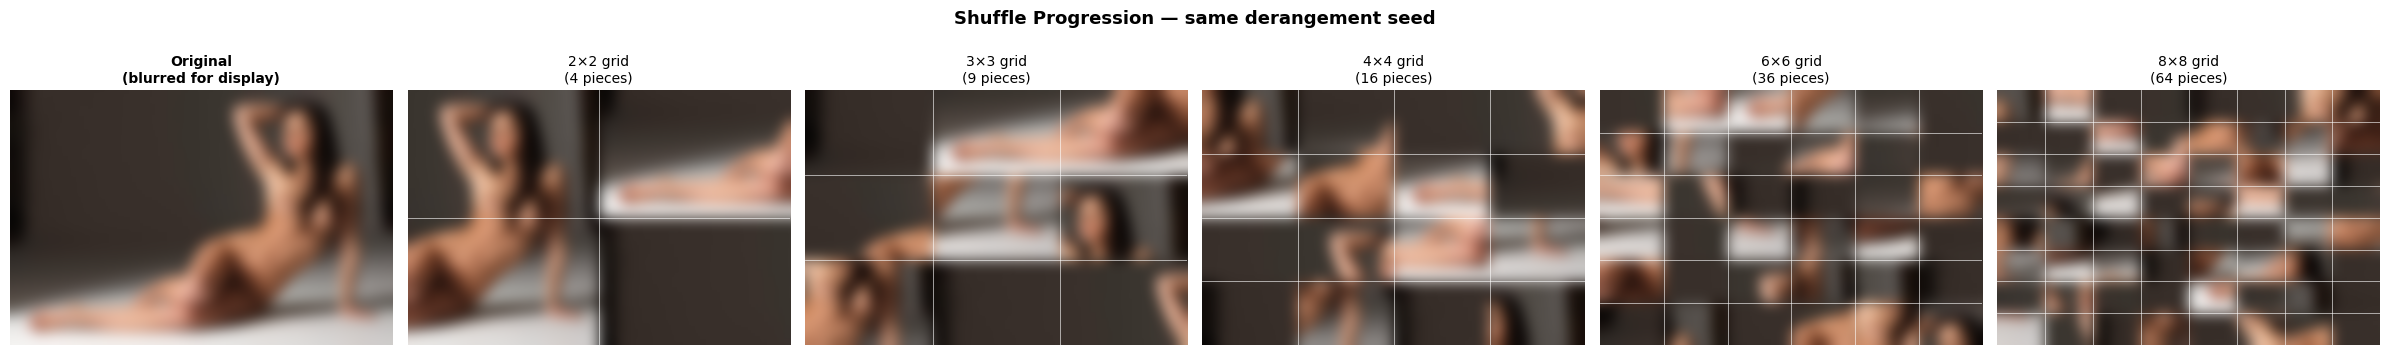

In [5]:
from PIL import ImageFilter

n_cols = len(GRID_SIZES) + 1   # original + one per grid size
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

# Original (blurred)
axes[0].imshow(original.filter(ImageFilter.GaussianBlur(18)))
axes[0].set_title('Original\n(blurred for display)', fontsize=10, fontweight='bold')
axes[0].axis('off')

for ax, grid_n in zip(axes[1:], GRID_SIZES):
    ax.imshow(shuffled_images[grid_n].filter(ImageFilter.GaussianBlur(18)))
    ax.set_title(f'{grid_n}×{grid_n} grid\n({grid_n**2} pieces)', fontsize=10)
    ax.axis('off')
    # Draw grid lines
    W, H = shuffled_images[grid_n].size
    for i in range(1, grid_n):
        ax.axvline(i * W / grid_n, color='white', linewidth=0.6, alpha=0.7)
        ax.axhline(i * H / grid_n, color='white', linewidth=0.6, alpha=0.7)

plt.suptitle('Shuffle Progression — same derangement seed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shuffle_progression.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Run All Models on Every Shuffled Image

In [6]:
# results[model][grid_n] = DetectionResult
results: dict[str, dict] = {}

# Also run on the original for baseline
all_grid_sizes = ['original'] + GRID_SIZES

for model_name in MODELS:
    print(f'\n{"─"*55}\n  {model_name}\n{"─"*55}')
    results[model_name] = {}
    try:
        detector = create_detector(model_name, threshold=THRESHOLD)

        # Baseline: original image
        r = detector.predict(str(SOURCE_IMAGE))
        results[model_name]['original'] = r
        print(f'  original          conf={r.confidence:.3f}  nudity={r.contains_nudity}')

        # Shuffled variants
        for grid_n in GRID_SIZES:
            r = detector.predict(str(shuffled_paths[grid_n]))
            results[model_name][grid_n] = r
            delta = r.confidence - results[model_name]['original'].confidence
            print(f'  {grid_n}×{grid_n} ({grid_n**2:2d} pieces)   conf={r.confidence:.3f}  '
                  f'nudity={r.contains_nudity}  Δ={delta:+.3f}')

    except Exception as e:
        print(f'  ERROR: {e}')
        results[model_name] = None

print('\nDone.')


───────────────────────────────────────────────────────
  nudenet
───────────────────────────────────────────────────────
  original          conf=0.827  nudity=True
  2×2 ( 4 pieces)   conf=0.841  nudity=True  Δ=+0.015
  3×3 ( 9 pieces)   conf=0.725  nudity=True  Δ=-0.102
  4×4 (16 pieces)   conf=0.651  nudity=False  Δ=-0.176
  6×6 (36 pieces)   conf=0.558  nudity=False  Δ=-0.268
  8×8 (64 pieces)   conf=0.688  nudity=False  Δ=-0.138

───────────────────────────────────────────────────────
  nudedetector
───────────────────────────────────────────────────────


objc[13423]: Class AVFFrameReceiver is implemented in both /opt/anaconda3/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x11a3283a8) and /opt/anaconda3/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x149eb43a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[13423]: Class AVFAudioReceiver is implemented in both /opt/anaconda3/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x11a3283f8) and /opt/anaconda3/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x149eb43f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /AdamCodd/vit-base-nsfw-detector/resolve/main/config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x325539fd0>: Fa

  original          conf=0.999  nudity=True
  2×2 ( 4 pieces)   conf=0.998  nudity=True  Δ=-0.001
  3×3 ( 9 pieces)   conf=0.998  nudity=True  Δ=-0.000
  4×4 (16 pieces)   conf=0.995  nudity=True  Δ=-0.004
  6×6 (36 pieces)   conf=0.992  nudity=True  Δ=-0.007
  8×8 (64 pieces)   conf=0.993  nudity=True  Δ=-0.005

───────────────────────────────────────────────────────
  laion_nsfw
───────────────────────────────────────────────────────


'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /Falconsai/nsfw_image_detection/resolve/main/config.json (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1028)')))"), '(Request ID: e7827cf7-48df-42b2-a1d3-6580556d16dc)')' thrown while requesting HEAD https://huggingface.co/Falconsai/nsfw_image_detection/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /Falconsai/nsfw_image_detection/resolve/main/config.json (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1028)')))"), '(Request ID: 1cf5709f-6a06-49ee-b7dd-3106e6346674)')' thrown while requesting HEAD https://huggingface.co/Falconsai/nsfw_image_detection/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(MaxRetryError("HTTPSConnectionPool(h

  original          conf=1.000  nudity=True
  2×2 ( 4 pieces)   conf=0.999  nudity=True  Δ=-0.001
  3×3 ( 9 pieces)   conf=0.985  nudity=True  Δ=-0.015
  4×4 (16 pieces)   conf=0.999  nudity=True  Δ=-0.000
  6×6 (36 pieces)   conf=1.000  nudity=True  Δ=+0.000
  8×8 (64 pieces)   conf=0.980  nudity=True  Δ=-0.020

───────────────────────────────────────────────────────
  open_nsfw
───────────────────────────────────────────────────────
  original          conf=0.998  nudity=True
  2×2 ( 4 pieces)   conf=0.999  nudity=True  Δ=+0.001
  3×3 ( 9 pieces)   conf=0.964  nudity=True  Δ=-0.034
  4×4 (16 pieces)   conf=0.979  nudity=True  Δ=-0.019
  6×6 (36 pieces)   conf=0.995  nudity=True  Δ=-0.003
  8×8 (64 pieces)   conf=0.172  nudity=False  Δ=-0.826

Done.


## 5. Confidence vs Grid Size — Line Plot

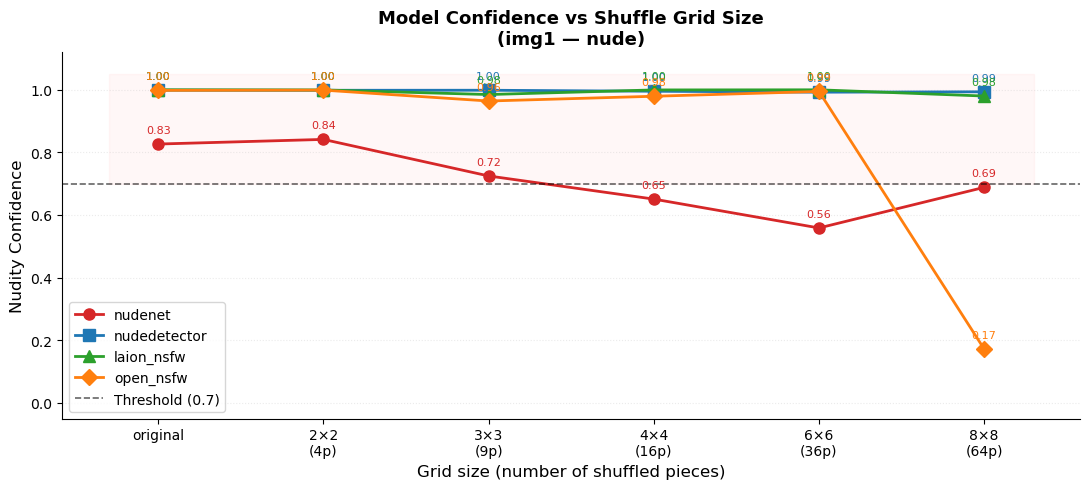

In [12]:
valid_models = [m for m in MODELS if results.get(m)]
colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']
markers = ['o', 's', '^', 'D']

# x-axis: 0 = original, then number of pieces
x_pieces = [1] + [n*n for n in GRID_SIZES]   # 1 piece = original
x_labels = ['original'] + [f'{n}×{n}\n({n**2}p)' for n in GRID_SIZES]
x_pos    = list(range(len(x_pieces)))

fig, ax = plt.subplots(figsize=(11, 5))

for m, color, marker in zip(valid_models, colors, markers):
    confs = [results[m]['original'].confidence] + [
        results[m][g].confidence for g in GRID_SIZES
    ]
    ax.plot(x_pos, confs, marker=marker, color=color, linewidth=2,
            markersize=8, label=m)
    # Annotate each point
    for xi, c in zip(x_pos, confs):
        ax.annotate(f'{c:.2f}', (xi, c), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8, color=color)

ax.axhline(THRESHOLD, color='black', linewidth=1.2, linestyle='--',
           label=f'Threshold ({THRESHOLD})', alpha=0.6)
ax.fill_between([-0.3, len(x_pos)-0.7], THRESHOLD, 1.05,
                color='red', alpha=0.03)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylabel('Nudity Confidence', fontsize=12)
ax.set_xlabel('Grid size (number of shuffled pieces)', fontsize=12)
ax.set_title('Model Confidence vs Shuffle Grid Size\n(img1 — nude)', fontsize=13, fontweight='bold')
ax.set_ylim(-0.05, 1.12)
ax.legend(fontsize=10, loc='lower left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle=':')

plt.tight_layout()
plt.savefig('shuffle_confidence_line.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Confidence Drop Heatmap

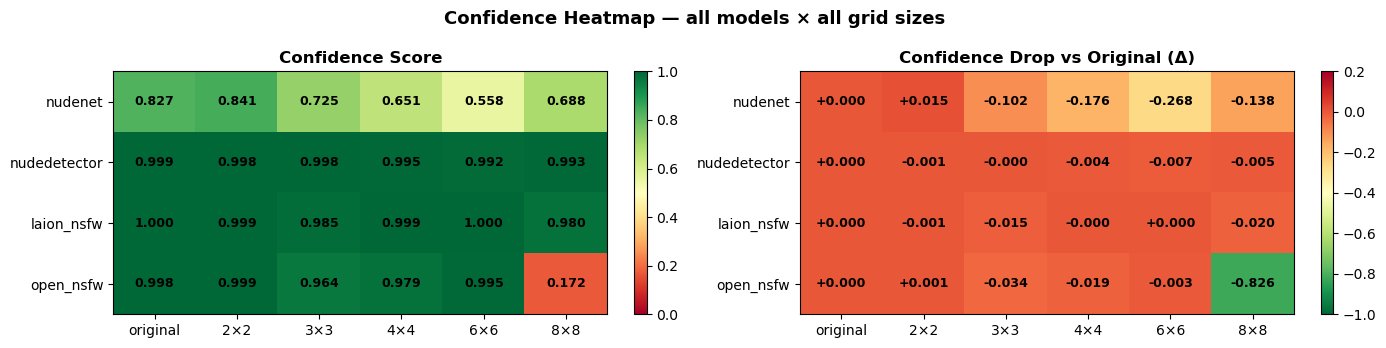

In [8]:
# Matrix: rows=models, cols=grid sizes, values=confidence
col_labels = ['original'] + [f'{n}×{n}' for n in GRID_SIZES]
matrix = np.array([
    [results[m]['original'].confidence] + [results[m][g].confidence for g in GRID_SIZES]
    for m in valid_models
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3.5))

# ── Raw confidence ─────────────────────────────────────────────────────────
im1 = ax1.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax1.set_xticks(range(len(col_labels)))
ax1.set_xticklabels(col_labels, fontsize=10)
ax1.set_yticks(range(len(valid_models)))
ax1.set_yticklabels(valid_models, fontsize=10)
ax1.set_title('Confidence Score', fontsize=12, fontweight='bold')
for i in range(len(valid_models)):
    for j in range(len(col_labels)):
        ax1.text(j, i, f'{matrix[i,j]:.3f}', ha='center', va='center',
                 fontsize=9, fontweight='bold', color='black')
plt.colorbar(im1, ax=ax1, fraction=0.04)

# ── Drop from baseline ─────────────────────────────────────────────────────
drop_matrix = matrix - matrix[:, 0:1]   # delta vs original
im2 = ax2.imshow(drop_matrix, cmap='RdYlGn_r', vmin=-1, vmax=0.2, aspect='auto')
ax2.set_xticks(range(len(col_labels)))
ax2.set_xticklabels(col_labels, fontsize=10)
ax2.set_yticks(range(len(valid_models)))
ax2.set_yticklabels(valid_models, fontsize=10)
ax2.set_title('Confidence Drop vs Original (Δ)', fontsize=12, fontweight='bold')
for i in range(len(valid_models)):
    for j in range(len(col_labels)):
        ax2.text(j, i, f'{drop_matrix[i,j]:+.3f}', ha='center', va='center',
                 fontsize=9, fontweight='bold', color='black')
plt.colorbar(im2, ax=ax2, fraction=0.04)

plt.suptitle('Confidence Heatmap — all models × all grid sizes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shuffle_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Side-by-Side: Shuffled Image + Per-Model Score

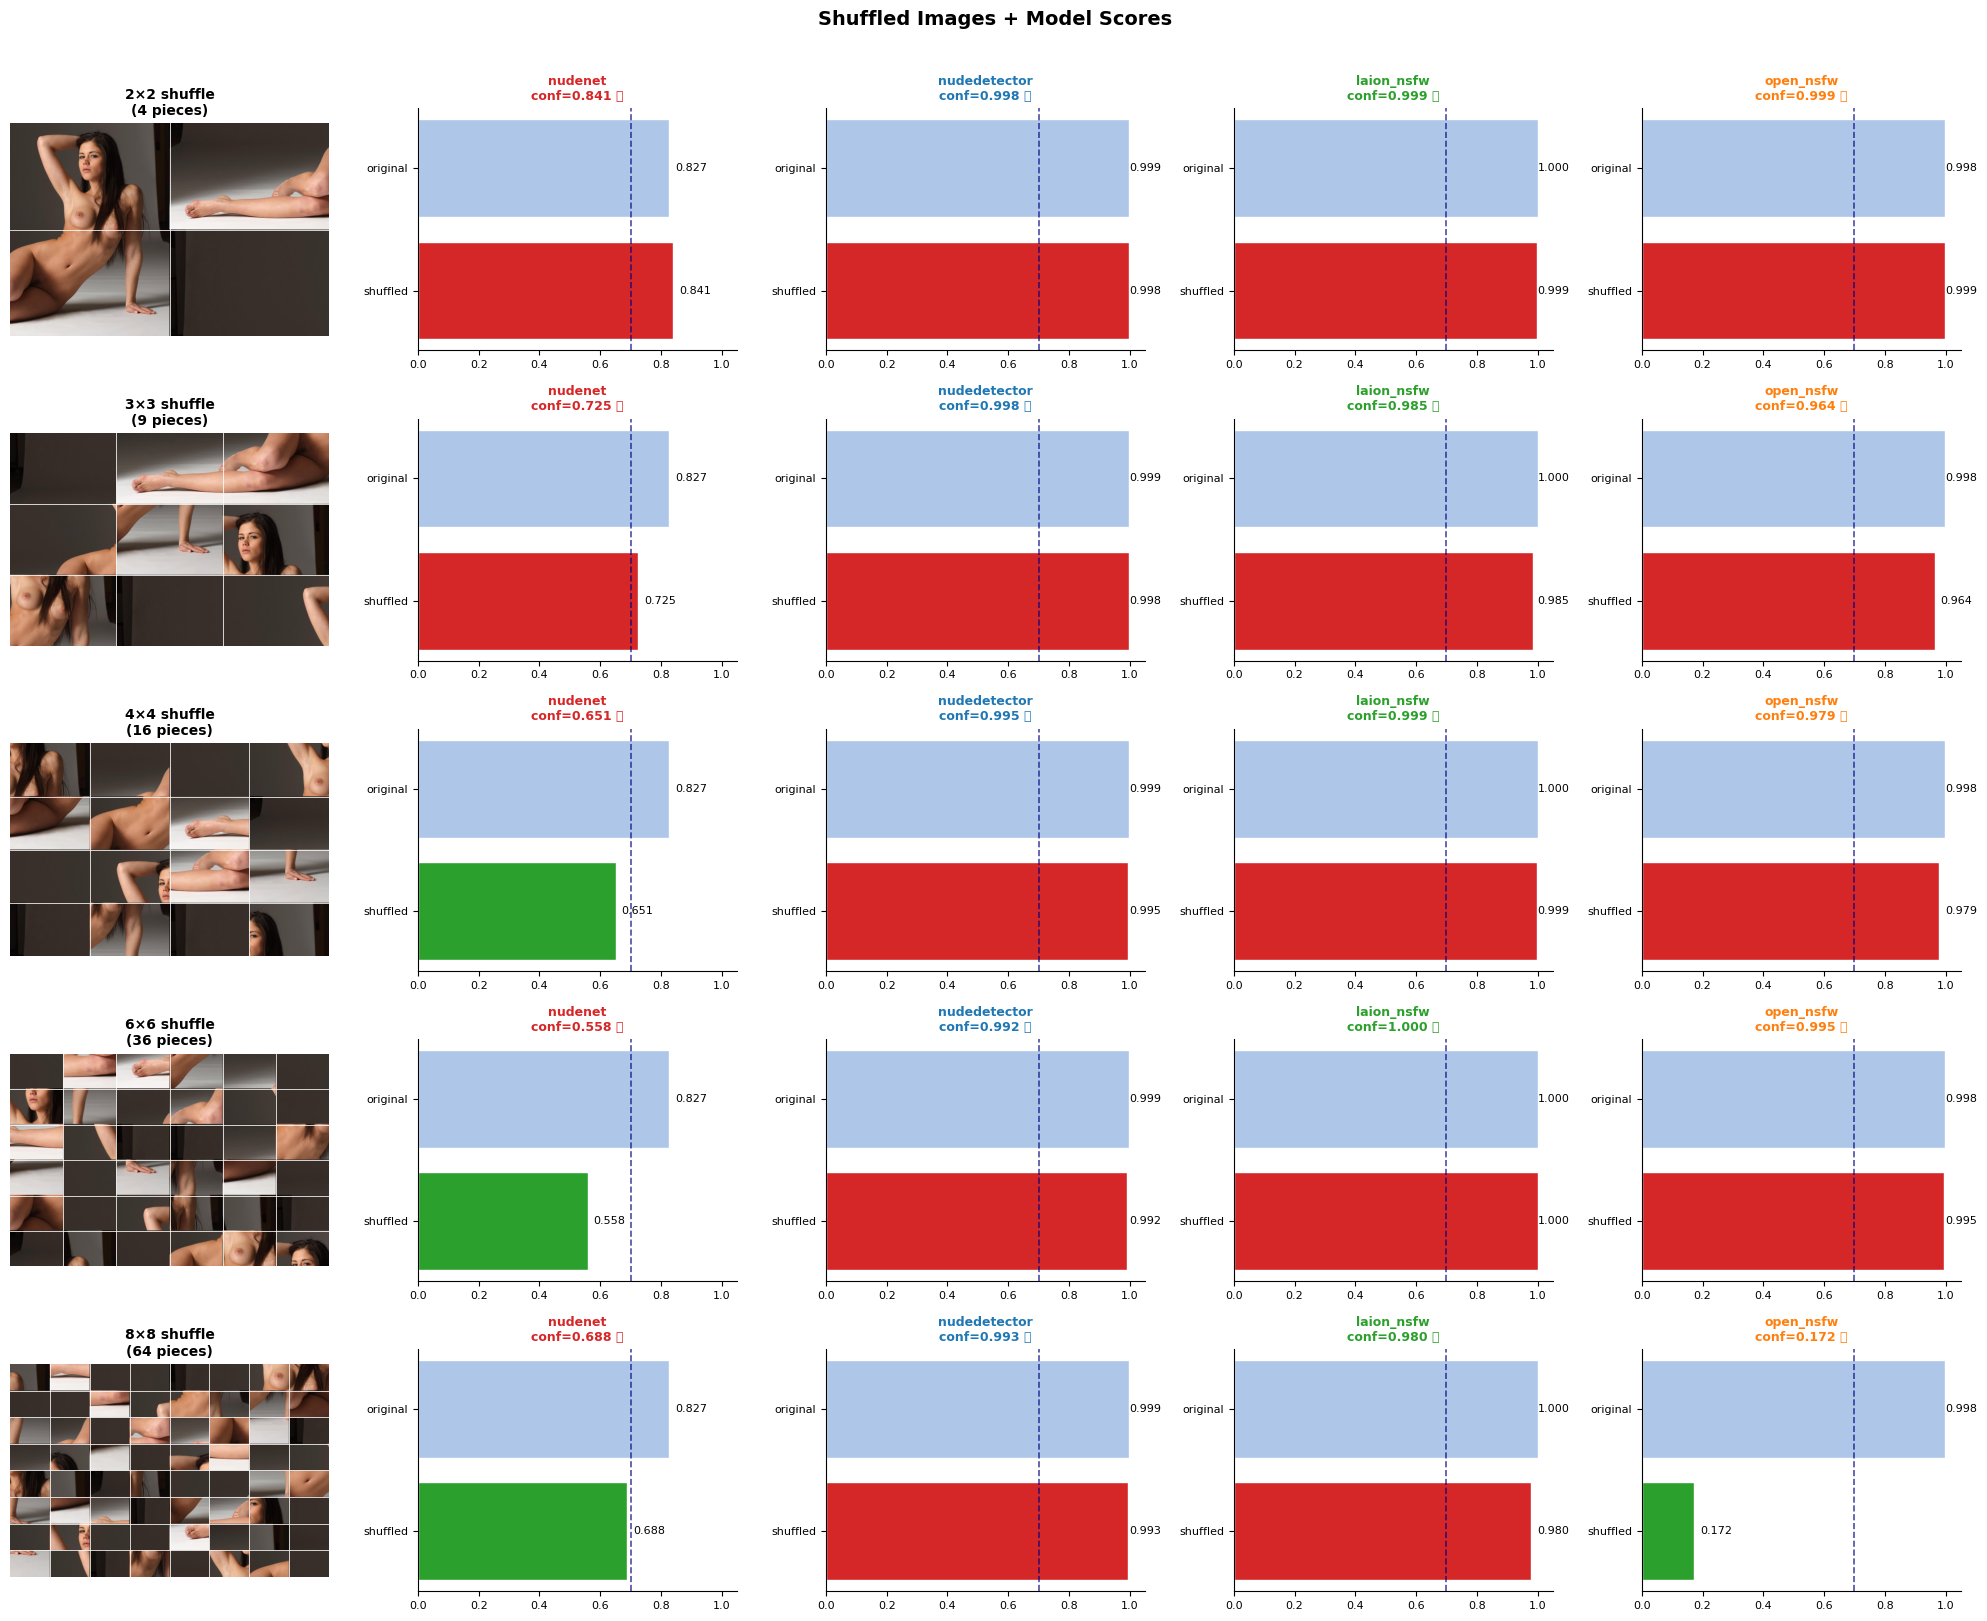

In [9]:
n_rows = len(GRID_SIZES)
n_cols = 1 + len(valid_models)   # image + one bar per model

fig = plt.figure(figsize=(4 * n_cols, 3.2 * n_rows))

for row_i, grid_n in enumerate(GRID_SIZES):
    # ── Shuffled image thumbnail ──────────────────────────────────────────
    ax_img = fig.add_subplot(n_rows, n_cols, row_i * n_cols + 1)
    ax_img.imshow(shuffled_images[grid_n])
    ax_img.set_title(f'{grid_n}×{grid_n} shuffle\n({grid_n**2} pieces)', fontsize=10, fontweight='bold')
    ax_img.axis('off')
    # Grid lines
    W, H = shuffled_images[grid_n].size
    for i in range(1, grid_n):
        ax_img.axvline(i * W / grid_n, color='white', lw=0.7, alpha=0.8)
        ax_img.axhline(i * H / grid_n, color='white', lw=0.7, alpha=0.8)

    # ── Bar per model ─────────────────────────────────────────────────────
    for col_i, (m, color) in enumerate(zip(valid_models, colors)):
        ax = fig.add_subplot(n_rows, n_cols, row_i * n_cols + col_i + 2)
        orig_conf = results[m]['original'].confidence
        shuf_conf = results[m][grid_n].confidence
        nudity    = results[m][grid_n].contains_nudity

        bar_color = '#d62728' if nudity else '#2ca02c'
        ax.barh(['shuffled', 'original'], [shuf_conf, orig_conf],
                color=[bar_color, '#aec7e8'], edgecolor='white')
        ax.axvline(THRESHOLD, color='navy', lw=1.2, linestyle='--', alpha=0.7)
        ax.set_xlim(0, 1.05)
        ax.set_title(f'{m}\nconf={shuf_conf:.3f} {"🔴" if nudity else "🟢"}',
                     fontsize=9, color=color, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=8)
        for val, y in zip([shuf_conf, orig_conf], [0, 1]):
            ax.text(min(val + 0.02, 1.0), y, f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Shuffled Images + Model Scores', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shuffle_image_scores.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. Spatial Sensitivity Summary

In [10]:
print('=' * 65)
print('SPATIAL SENSITIVITY SUMMARY')
print('How much does confidence drop as the image is shuffled more?')
print('=' * 65)

for m in valid_models:
    baseline = results[m]['original'].confidence
    finest   = results[m][GRID_SIZES[-1]].confidence   # most shuffled
    total_drop = baseline - finest

    # Count how many grid sizes still detect nudity
    still_detects = sum(
        1 for g in GRID_SIZES if results[m][g].contains_nudity
    )

    print(f'\n{m}')
    print(f'  Baseline ({"original":>10})  : {baseline:.3f}')
    for g in GRID_SIZES:
        c = results[m][g].confidence
        flag = '✅' if results[m][g].contains_nudity else '❌'
        print(f'  {g}×{g} grid  ({g**2:2d} pieces) : {c:.3f}  {flag}  (Δ={c-baseline:+.3f})')
    print(f'  Total drop (orig → {GRID_SIZES[-1]}×{GRID_SIZES[-1]}) : {total_drop:+.3f}')
    print(f'  Still detects nudity in {still_detects}/{len(GRID_SIZES)} shuffled variants')

    sensitivity = 'HIGH (global features)' if total_drop > 0.3 else \
                  'MEDIUM'                 if total_drop > 0.1 else \
                  'LOW (local features)'
    print(f'  Spatial sensitivity: {sensitivity}')

print('\n' + '=' * 65)

SPATIAL SENSITIVITY SUMMARY
How much does confidence drop as the image is shuffled more?

nudenet
  Baseline (  original)  : 0.827
  2×2 grid  ( 4 pieces) : 0.841  ✅  (Δ=+0.015)
  3×3 grid  ( 9 pieces) : 0.725  ✅  (Δ=-0.102)
  4×4 grid  (16 pieces) : 0.651  ❌  (Δ=-0.176)
  6×6 grid  (36 pieces) : 0.558  ❌  (Δ=-0.268)
  8×8 grid  (64 pieces) : 0.688  ❌  (Δ=-0.138)
  Total drop (orig → 8×8) : +0.138
  Still detects nudity in 2/5 shuffled variants
  Spatial sensitivity: MEDIUM

nudedetector
  Baseline (  original)  : 0.999
  2×2 grid  ( 4 pieces) : 0.998  ✅  (Δ=-0.001)
  3×3 grid  ( 9 pieces) : 0.998  ✅  (Δ=-0.000)
  4×4 grid  (16 pieces) : 0.995  ✅  (Δ=-0.004)
  6×6 grid  (36 pieces) : 0.992  ✅  (Δ=-0.007)
  8×8 grid  (64 pieces) : 0.993  ✅  (Δ=-0.005)
  Total drop (orig → 8×8) : +0.005
  Still detects nudity in 5/5 shuffled variants
  Spatial sensitivity: LOW (local features)

laion_nsfw
  Baseline (  original)  : 1.000
  2×2 grid  ( 4 pieces) : 0.999  ✅  (Δ=-0.001)
  3×3 grid  ( 9 piec